In [5]:
!pip install streamlit pyngrok scikit-learn pandas numpy matplotlib joblib -q
!apt-get install -y fonts-nanum -q
# matplotlib 폰트 캐시 초기화 (폰트 인식을 위해 필요)
import shutil, matplotlib
shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df  = pd.read_csv(url).dropna()


FEATURES = ['Adult mortality', 'BMI', 'GDP', 'Alcohol']
TARGET   = 'Life expectancy'

X = df[FEATURES].values
y = df[TARGET].values


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

np.random.seed(42)
idx     = np.random.choice(len(X_train_full), 50, replace=False)
X_train = X_train_full[idx]
y_train = y_train_full[idx]

print(f"전체 데이터: {len(df)}개")
print(f"훈련(50샘플): {X_train.shape}  /  테스트: {X_test.shape}")


model_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

model_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('linear', LinearRegression())
])


model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('ridge',  Ridge(alpha=1.0))
])

model_linear.fit(X_train, y_train)
model_poly.fit(X_train,   y_train)
model_ridge.fit(X_train,  y_train)
print(" 모델 학습 완료")


print("\n=== 성능 평가 결과 ===")
for name, model in [("Linear", model_linear),
                    ("Poly",   model_poly),
                    ("Ridge",  model_ridge)]:
    tr2  = r2_score(y_train, model.predict(X_train))
    te2  = r2_score(y_test,  model.predict(X_test))
    tmse = mean_squared_error(y_train, model.predict(X_train))
    emse = mean_squared_error(y_test,  model.predict(X_test))
    comp = (model.named_steps['poly'].n_output_features_
            if 'poly' in model.named_steps else len(FEATURES))
    print(f"[{name}]  Train R²={tr2:.4f}  Test R²={te2:.4f}"
          f"  Train MSE={tmse:.2f}  Test MSE={emse:.2f}  Complexity={comp}")


joblib.dump(model_linear, 'model_linear.pkl')
joblib.dump(model_poly,   'model_poly.pkl')
joblib.dump(model_ridge,  'model_ridge.pkl')

feature_stats = {
    'features': FEATURES,
    'min':  df[FEATURES].min().to_dict(),
    'max':  df[FEATURES].max().to_dict(),
    'mean': df[FEATURES].mean().to_dict(),
}
joblib.dump(feature_stats, 'feature_stats.pkl')

results_data = {}
for name, model in [("Linear", model_linear),
                    ("Poly",   model_poly),
                    ("Ridge",  model_ridge)]:
    tr2  = r2_score(y_train, model.predict(X_train))
    te2  = r2_score(y_test,  model.predict(X_test))
    tmse = mean_squared_error(y_train, model.predict(X_train))
    emse = mean_squared_error(y_test,  model.predict(X_test))
    comp = (model.named_steps['poly'].n_output_features_
            if 'poly' in model.named_steps else len(FEATURES))
    results_data[name] = {
        'Train R2':   round(tr2,  4),
        'Test R2':    round(te2,  4),
        'Train MSE':  round(tmse, 2),
        'Test MSE':   round(emse, 2),
        'Complexity': comp
    }
joblib.dump(results_data, 'model_results.pkl')

print("\n 저장 완료: model_linear.pkl / model_poly.pkl / model_ridge.pkl")
print(" feature_stats.pkl / model_results.pkl")


전체 데이터: 1649개
훈련(50샘플): (50, 4)  /  테스트: (330, 4)
 모델 학습 완료

=== 성능 평가 결과 ===
[Linear]  Train R²=0.7336  Test R²=0.5794  Train MSE=29.22  Test MSE=29.87  Complexity=4
[Poly]  Train R²=0.9617  Test R²=-476.5808  Train MSE=4.20  Test MSE=33918.97  Complexity=34
[Ridge]  Train R²=0.9238  Test R²=0.1230  Train MSE=8.36  Test MSE=62.28  Complexity=34

 저장 완료: model_linear.pkl / model_poly.pkl / model_ridge.pkl
 feature_stats.pkl / model_results.pkl


In [3]:
%%writefile app.py

import os
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import joblib
from sklearn.metrics import r2_score, mean_squared_error
from PIL import Image

Image.MAX_IMAGE_PIXELS = None


FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

def set_korean_font():
    if os.path.exists(FONT_PATH):
        fm.fontManager.addfont(FONT_PATH)
        plt.rcParams['font.family']        = 'NanumGothic'
    else:

        plt.rcParams['font.family']        = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()


st.set_page_config(page_title="기대수명 예측 서비스", layout="wide")
st.title(" WHO 기대수명 예측 AI 서비스")
st.markdown(
    "수업 파이프라인 **(Linear / Poly / Ridge)** 을 활용한 "
    "**다중 특성 회귀 분석** 대시보드"
)

@st.cache_resource
def load_all():
    m_linear = joblib.load('model_linear.pkl')
    m_poly   = joblib.load('model_poly.pkl')
    m_ridge  = joblib.load('model_ridge.pkl')
    stats    = joblib.load('feature_stats.pkl')
    results  = joblib.load('model_results.pkl')
    return m_linear, m_poly, m_ridge, stats, results

model_linear, model_poly, model_ridge, feature_stats, model_results = load_all()

models_dict = {
    "Linear (1차 선형 회귀)":         model_linear,
    "Poly (3차 다항 회귀, 규제없음)":  model_poly,
    "Ridge (3차 다항 + Ridge 규제)":   model_ridge,
}

FEATURES = feature_stats['features']

st.sidebar.header(" 입력값 설정")

selected_model_name = st.sidebar.selectbox(
    " 예측 모델 선택",
    list(models_dict.keys())
)
selected_model = models_dict[selected_model_name]

st.sidebar.markdown("---")
st.sidebar.subheader(" 특성값 조절")


slider_configs = {
    'Adult mortality': ("Adult mortality (성인 사망률)", 1.0,    723.0,  168.0),
    'BMI':             ("BMI (체질량지수)",              2.0,     77.0,   38.0),
    'GDP':             ("GDP (달러)",                    1.0, 120000.0, 5566.0),
    'Alcohol':         ("Alcohol (알코올 소비량)",        0.0,     18.0,    4.5),
}

user_inputs = {}
for feat in FEATURES:
    label, mn, mx, default = slider_configs[feat]
    user_inputs[feat] = st.sidebar.slider(label, mn, mx, default)


input_array = np.array([[user_inputs[f] for f in FEATURES]])
prediction  = selected_model.predict(input_array)[0]


col1, col2 = st.columns([1, 2])

with col1:
    st.subheader(" 예측 결과")
    st.metric(
        label=f"모델: {selected_model_name.split('(')[0].strip()}",
        value=f"{prediction:.2f} 세",
        delta=f"{prediction - 69.3:.2f} (세계 평균 대비)"
    )
    st.markdown("---")
    st.write("** 입력된 특성값 요약**")
    input_df = pd.DataFrame({
        '특성':  FEATURES,
        '입력값': [round(user_inputs[f], 2) for f in FEATURES]
    })
    st.dataframe(input_df, use_container_width=True)

with col2:
    st.subheader(" 입력값 상대 수준")

    f_min  = np.array([slider_configs[f][1] for f in FEATURES])
    f_max  = np.array([slider_configs[f][2] for f in FEATURES])
    norm_v = (np.array([user_inputs[f] for f in FEATURES]) - f_min) / (f_max - f_min)


    fig1, ax1 = plt.subplots(figsize=(5, 2.8), dpi=100)
    bars1 = ax1.barh(FEATURES, norm_v, color='steelblue', alpha=0.75)
    ax1.set_xlim(0, 1.15)
    ax1.set_xlabel("Normalized value (0~1)")
    ax1.set_title("Input Feature Relative Level")
    for bar, val in zip(bars1, norm_v):
        ax1.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=9)
    fig1.tight_layout()
    st.pyplot(fig1)
    plt.close(fig1)

st.markdown("---")
st.subheader(" 모델 성능 비교")

perf_df = pd.DataFrame(model_results).T.reset_index()
perf_df.columns = ['Model', 'Train R2', 'Test R2', 'Train MSE', 'Test MSE', 'Complexity']
st.dataframe(perf_df, use_container_width=True)


st.subheader(" Test R² 점수 비교 (Bar Chart)")

model_names  = list(model_results.keys())
display_r2_vals = [max(model_results[m]['Test R2'], -5)for m in model_names]
colors       = ['#4C72B0', '#DD8452', '#55A868']


fig2, ax2 = plt.subplots(figsize=(6, 3), dpi=100)

bars2 = ax2.bar(model_names,display_r2_vals,color=colors,alpha=0.85,edgecolor='black',width=0.5)

ax2.set_ylim(min(display_r2_vals) - abs(min(display_r2_vals)) * 0.1 - 0.5, 1.2)
ax2.set_ylabel("Test R2 Score")
ax2.set_title("3-Model Test R2 Comparison\n"
              "(Higher is better / Negative = Overfitting)")
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1.0)

for bar, real_val, display_val in zip(bars2,display_r2_vals,display_r2_vals):

    ax2.text(bar.get_x() + bar.get_width()/2,display_val + 0.1,f'{real_val:.4f}',ha='center')

fig2.tight_layout()
st.pyplot(fig2)
plt.close(fig2)

st.info(
    "**Model Interpretation**\n\n"
    "- **Linear**: Stable but simple → possible underfitting\n"
    "- **Poly (no regularization)**: Train R2≈1 but Test R2 negative → **Overfitting**\n"
    "- **Ridge (regularized)**: Ridge penalty suppresses overfitting → best generalization"
)

st.markdown("---")
st.caption(
    "Assignment | WHO Life Expectancy Dataset | "
    "scikit-learn Pipeline + Streamlit"
)


Writing app.py


In [4]:


import os, time, subprocess, urllib.request, urllib.error, json, base64
from pyngrok import ngrok

NGROK_TOKEN = "3DymICmdFjvI4NnonCNSbhyKb81_ongtfTGKe1j1TAeGE94n"

subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
subprocess.run(['pkill', '-f', 'ngrok'],     capture_output=True)
time.sleep(2)



def ngrok_api(method, path, token):
    url = f"https://api.ngrok.com{path}"
    req = urllib.request.Request(url, method=method)
    req.add_header("Authorization",  f"Bearer {token}")
    req.add_header("Ngrok-Version",  "2")
    req.add_header("Content-Type",   "application/json")
    try:
        with urllib.request.urlopen(req, timeout=10) as r:
            return json.loads(r.read().decode()) if r.length else {}
    except urllib.error.HTTPError as e:
        body = e.read().decode()
        print(f"  API {method} {path} → {e.code}: {body[:120]}")
        return None

result = ngrok_api("GET", "/endpoints", NGROK_TOKEN)
if result and "endpoints" in result:
    eps = result["endpoints"]
    if eps:
        for ep in eps:
            ep_id  = ep.get("id", "")
            ep_url = ep.get("public_url", ep.get("url", ""))
            print(f"  삭제: {ep_url} (id={ep_id})")
            ngrok_api("DELETE", f"/endpoints/{ep_id}", NGROK_TOKEN)
        print(f"  총 {len(eps)}개 엔드포인트 삭제 완료")
    else:
        print("  활성 엔드포인트 없음")
else:
    print("  엔드포인트 조회 실패 (토큰 확인 필요)")

time.sleep(3)
print("▶ Step3: Streamlit 시작 중...")
ngrok.set_auth_token(NGROK_TOKEN)

os.system(
    "nohup streamlit run app.py "
    "--server.address 127.0.0.1 "
    "--server.port 8501 > streamlit.log 2>&1 &"
)
time.sleep(4)

try:
    public_url = ngrok.connect(8501, bind_tls=True)
    print("=" * 60)
    print(f"배포 완료!\n{public_url}")
    print("=" * 60)
except Exception as e:
    print(f" 터널 연결 실패: {e}")
    print("→ 잠시 후 이 셀만 다시 실행하거나,")
    print("  https://dashboard.ngrok.com 에서 직접 엔드포인트를 삭제하세요.")


  API GET /endpoints → 400: {"error_code":"ERR_NGROK_206","status_code":400,"msg":"The authentication you specified is actually an authtoken. Your c
  엔드포인트 조회 실패 (토큰 확인 필요)
▶ Step3: Streamlit 시작 중...
배포 완료!
NgrokTunnel: "https://cage-gambling-county.ngrok-free.dev" -> "http://localhost:8501"


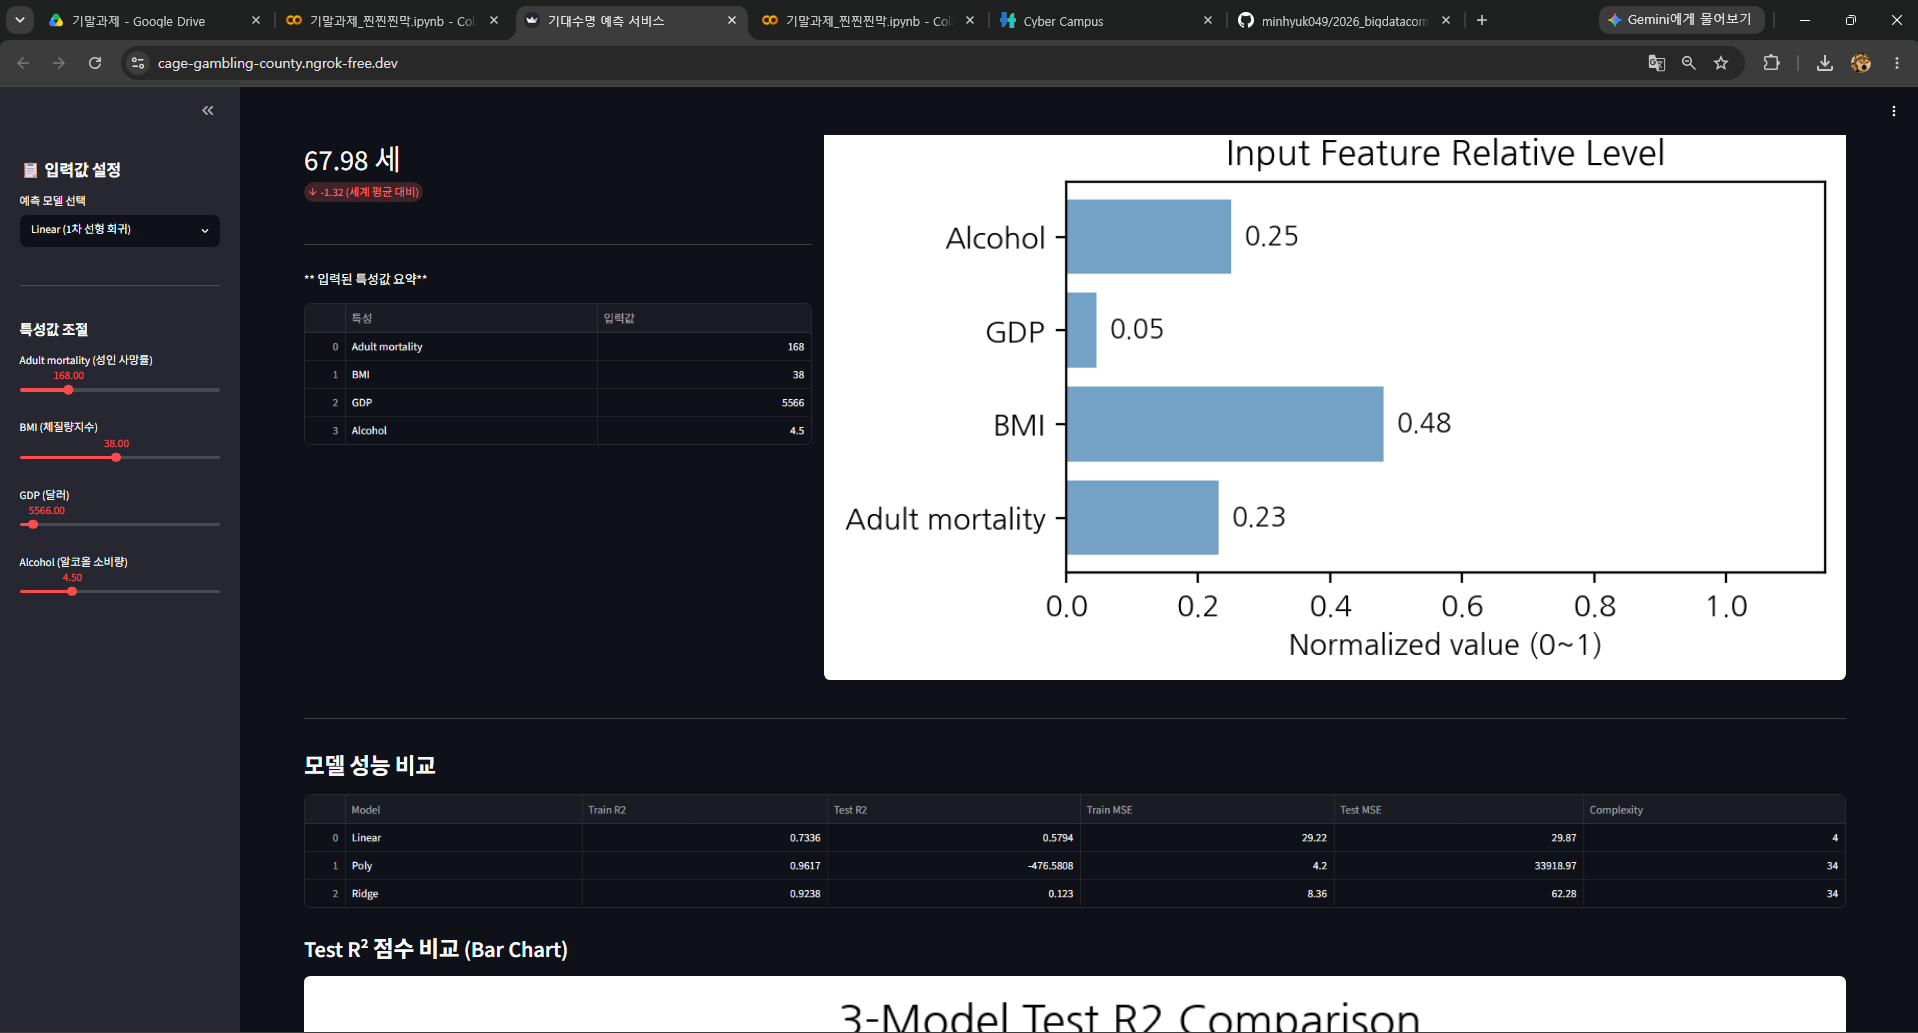